# Fitting SMT Residence Time Data

In [25]:
import multiprocessing as mp
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pytensor
import pymc as pm
import arviz as az
import math
from tqdm import tqdm  # Importing tqdm for progress bar tracking
import seaborn as sns
from statannotations.Annotator import Annotator
import logging
import tempfile
import shutil
import numpyro
import jax
import jaxlib
import os

In [26]:
os.chdir('/Users/samuelhunter/ERalpha_Steiner2025/')

## SIMULATED DATA TO TEST FITS

### Fitting PDF

In [27]:
# Simulation and model fitting of histogram directly.
# Because we're fittng the histogram (PDF instead of survival function), we'll use (-1)*derivative of the double exponential for fitting.
# I'm including a "plateau" term as well, which represents uniform background noise.
# Mixture of two exponential distributions
def mixture_exponential(t, A, koff_fast, koff_slow, plateau):
    """
    Equation for double exponential + a uniform noise plateau

    Parameters:
    - t, Time array (x values)
    - A, Fraction of fast population
    - koff_fast, koff of fast population
    - koff_slow, koff of slow population
    - plateau, fraction of uniform noise
    """
    exp_fast = koff_fast * np.exp(-koff_fast * t)
    exp_slow = koff_slow * np.exp(-koff_slow * t)
    uniform_noise = plateau / (t.max() - t.min())
    return ((A - plateau) * exp_fast + (1 - A - plateau) * exp_slow + uniform_noise)


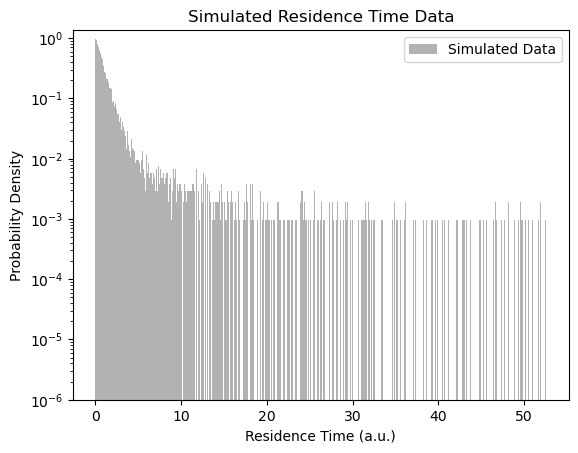

In [28]:
# Simulate synthetic data

# True parameters
A_true = 0.9  # Fraction of the "fast" population
B_true = 0.08  # Fraction of the "slow" population
C_true = 1 - A_true - B_true  # Fraction of the noise
koff_fast_true = 1.2  # Dissociation rate for fast population
koff_slow_true = 0.15  # Dissociation rate for slow population
n_samples = 10000  # Total number of samples

# Generate residence times
fast_population = np.random.exponential(1 / koff_fast_true, int(A_true * n_samples))
slow_population = np.random.exponential(1 / koff_slow_true, int(B_true * n_samples))
noise_population = np.random.uniform(np.concatenate([fast_population, slow_population]).min(), np.concatenate([fast_population, slow_population]).max(), int(C_true * n_samples))

# Combine and scramble data.

# Data with uniform noise
residence_times = np.concatenate([fast_population, slow_population, noise_population])
np.random.shuffle(residence_times)

# Plot histogram of simulated data
plt.hist((residence_times), bins=500, density=True, alpha=0.6, color="gray", label="Simulated Data")
#plt.hist(true_residence_times, bins=50, density=True, alpha=0.6, color="blue", label="De-noised Simulated Data")
plt.xlabel("Residence Time (a.u.)")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.ylim(1e-6)
plt.title("Simulated Residence Time Data")
plt.legend()
plt.show()

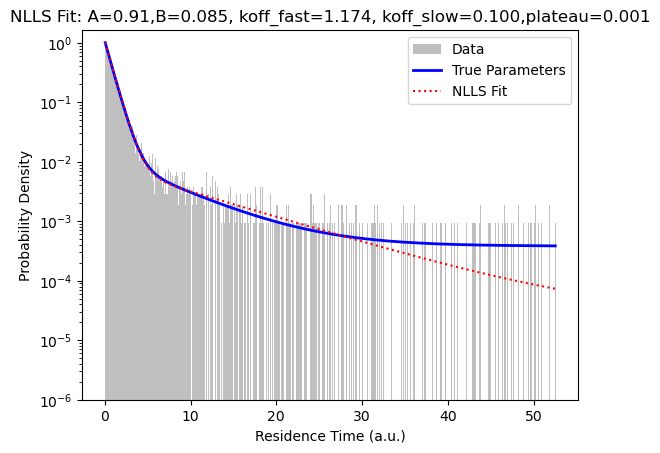

In [29]:
# Histogram data
# Fit for koff_slow is okay in NLLS
bin_num=500
hist, bin_edges = np.histogram(residence_times, bins=bin_num, density=True)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Fit the mixture model on the histogram
p0 = [0.8, 0.9, 0.1, 0.01]  # Initial guesses for amp, A, koff_fast, koff_slow, and plateau
popt, pcov = curve_fit(mixture_exponential, bin_centers, hist, p0=p0, bounds=((0,0,0,0),(1,np.inf,np.inf,1)))

A_fit, koff_fast_fit, koff_slow_fit, plateau_fit = popt

# Plot results
plt.hist(residence_times, bins=bin_num, density=True, alpha=0.5, color = "grey", label="Data")

true_value_fitted = mixture_exponential(bin_centers, A_true, koff_fast_true, koff_slow_true, C_true)
plt.plot(bin_centers, true_value_fitted, label="True Parameters", color="blue", linewidth=2, linestyle="solid")

plt.plot(bin_centers, mixture_exponential(bin_centers, *popt), label="NLLS Fit", color="red", linestyle="dotted")
plt.xlabel("Residence Time (a.u.)")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.ylim(1e-6)
plt.legend()
plt.title(f"NLLS Fit: A={A_fit:.2f},B={1-A_fit-plateau_fit:.3f}, koff_fast={koff_fast_fit:.3f}, koff_slow={koff_slow_fit:.3f},plateau={plateau_fit:.3f}")
plt.show()

# Fit is biased towards left of histogram


In [30]:
# Define bins
num_bins = 500  # Adjust as needed
bin_edges = np.linspace(residence_times.min(), residence_times.max(), num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers

# Compute histogram
hist_counts, _ = np.histogram(residence_times, bins=bin_edges)

with pm.Model() as model:
    # Priors
    alpha = np.array([1, 1, 1])  # Dirichlet prior for fractions
    weights = pm.Dirichlet("weights", a=alpha)

    # Exponential distributions for fast and slow populations
    koff_slow_lam = pm.Uniform("koff_slow_lam",lower=0,upper=10)
    koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
    koff_alpha = pm.Uniform("koff_alpha",lower=0,upper=10)
    koff_beta = pm.Uniform("koff_beta",lower=0,upper=10)

    koff_fast = pm.Gamma("koff_fast",alpha=koff_alpha,beta=koff_beta)    
    pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))
        
    # Constrained Uniform noise term: uniform noise between the minimum and maximum residence time
    noise_min = np.min(bin_centers)
    noise_max = np.max(bin_centers)
    noise_range = noise_max - noise_min  # Calculate the range of residence times
    
    # Noise fraction should be a fraction of the total population
    uniform_noise = 1/(noise_max - noise_min)
      
    # Expected probability density for each bin center
    expected_density = (
        weights[0] * koff_fast * pm.math.exp(-koff_fast * bin_centers) +
        weights[1] * koff_slow * pm.math.exp(-koff_slow * bin_centers) +
        weights[2] * uniform_noise  # Scaling noise fraction with the noise term
    )

    # Normalize to expected counts (scale by bin width and sample size)
    bin_width = np.diff(bin_edges)
    expected_counts = expected_density * bin_width * len(residence_times)

    # Likelihood: Observed histogram follows a Poisson distribution
    y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)

    # MCMC Sampling
    trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, nuts_sampler="nutpie")


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.38,15
,2000,0,0.36,3
,2000,0,0.39,15
,2000,0,0.38,15


In [31]:
# Summary statistics
summary = az.summary(
    trace, var_names=["weights", "koff_fast", "koff_slow"], round_to=4
)
print(summary)

              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
weights[0]  0.8909  0.0069  0.8773   0.9030     0.0002   0.0001  2156.7966   
weights[1]  0.0915  0.0063  0.0801   0.1035     0.0001   0.0001  2669.6937   
weights[2]  0.0176  0.0024  0.0134   0.0222     0.0000   0.0000  2353.7129   
koff_fast   1.2064  0.0184  1.1709   1.2402     0.0004   0.0003  2691.6949   
koff_slow   0.1617  0.0143  0.1345   0.1882     0.0003   0.0002  1874.8745   

             ess_tail   r_hat  
weights[0]  2378.8703  1.0002  
weights[1]  2775.1913  0.9998  
weights[2]  2229.5644  1.0012  
koff_fast   2662.0598  1.0005  
koff_slow   2326.8774  1.0002  


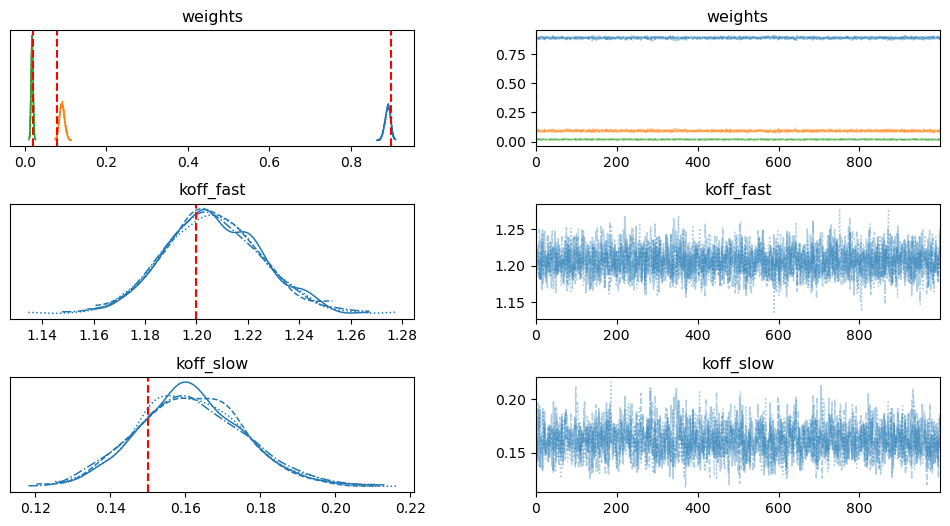

In [32]:
true_values = {
    "koff_fast": [koff_fast_true],
    "koff_slow": [koff_slow_true],
    "weights": [A_true, B_true, C_true]
}
az.plot_trace(trace, var_names=["weights", "koff_fast", "koff_slow"])
# Add vertical lines for true values
for param, true_value in true_values.items():
    plt.gcf()  
    axes = plt.gcf().axes  
    for ax in axes:
        if param in ax.get_title():
            for value in true_value:
                ax.axvline(value, color="red", linestyle="--", label="True Value")

plt.subplots_adjust(hspace=0.5, wspace=0.3)
plt.show()

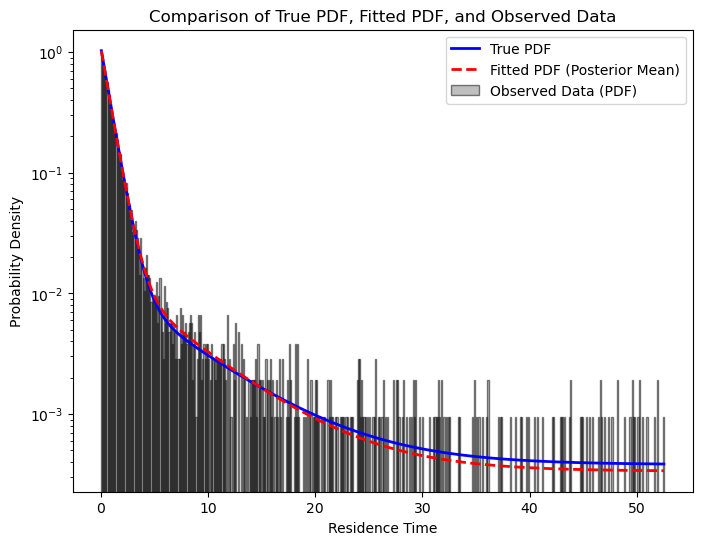

In [33]:
# Extract posterior means from the PyMC trace
weights_post = trace.posterior["weights"].mean(dim=("chain", "draw")).values
koff_slow_post = trace.posterior["koff_slow"].mean(dim=("chain", "draw")).values
koff_fast_post = trace.posterior["koff_fast"].mean(dim=("chain", "draw")).values
#noise_fraction_post = trace.posterior["noise_fraction"].mean(dim=("chain", "draw")).values


# Compute the fitted probability density function
fitted_pdf = (
    weights_post[0] * koff_fast_post * np.exp(-koff_fast_post * bin_centers) +
    weights_post[1] * koff_slow_post * np.exp(-koff_slow_post * bin_centers) +
    weights_post[2]/(residence_times.max() - residence_times.min())  # Normalized uniform noise
)

# Normalize histogram to probability density
hist_pdf, bin_edges = np.histogram(residence_times, bins=bin_edges, density=True)

# Compute the true PDF using true parameters
true_pdf = (
    A_true * koff_fast_true * np.exp(-koff_fast_true * bin_centers) +
    B_true * koff_slow_true * np.exp(-koff_slow_true * bin_centers) +
    C_true / (np.max(residence_times) - np.min(residence_times))  # True uniform noise contribution
)

# Plot results
plt.figure(figsize=(8, 6))

# Plot histogram as a PDF
plt.bar(bin_centers, hist_pdf, width=np.diff(bin_edges)[0], alpha=0.5, label="Observed Data (PDF)", color="gray", edgecolor="black")

# Plot true PDF
plt.plot(bin_centers, true_pdf, label="True PDF", color="blue", linestyle="solid", linewidth=2)

# Plot fitted PDF
plt.plot(bin_centers, fitted_pdf, label="Fitted PDF (Posterior Mean)", color="red", linestyle="dashed", linewidth=2)

plt.xlabel("Residence Time")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.legend()
plt.title("Comparison of True PDF, Fitted PDF, and Observed Data")
plt.show()


### Survival Curve Approach


In [34]:
def calculate_survival_probability(track_lengths, frame_interval=0.25, max_frames=500):
    """
    Calculate the survival probability using Cyna's method. Is this more or less what you're doing?

    Parameters:
    - track_lengths: an array of track lengths
    - frame_interval: Time per frame in seconds (default 0.25s).
    - max_frames: Maximum allowed frames for the movie (default 500 frames).

    Returns:
    - survival_df: DataFrame with time and survival probability.
    """
    bins = np.arange(1, max_frames)  # 1-frame increments from 1 to 499
    histogram_counts, bin_edges = np.histogram(track_lengths, bins=bins)
    cdf = np.cumsum(histogram_counts) / np.sum(histogram_counts)
    survival_probability = 1 - cdf

    # Exclude the last "filled" CDF bin to sync up bin length with time values
    survival_probability = survival_probability[:-1]

    # Time points are the floor of the time values per 1-CDF bin
    # Exclude the first and last bin edges, scale by frame interval
    time_values = (bin_edges[1:-1]) * frame_interval

    # Create a DataFrame for survival probability
    survival_df = pd.DataFrame({
        'time': time_values,
        'survival_probability': survival_probability
    })

    return survival_df

def plot_survival_curve(survival_df):
    """
    Plot the survival curve.

    Parameters:
    - survival_df: DataFrame containing time and survival probability.
    """
    plt.figure(figsize=(8, 6))
    plt.plot(
        survival_df['time'], 
        survival_df['survival_probability'], 
        label="Survival Curve",
        color="blue"
    )
    plt.xlabel("Time (a.u.)")
    plt.ylabel("Survival Probability")
    plt.title("Track Survival Curve")
    plt.legend()

def plot_fitted_survival(t, koff_fast, koff_slow, A, B, C, linestyle="dotted",color="red"):
    y_vals = (A) * np.exp(-koff_fast * t) + (B) * np.exp(-koff_slow * t) + (C/(t.max()-t.min()))
    plt.plot(t, y_vals, linestyle=linestyle, color=color)
    plt.yscale('log')

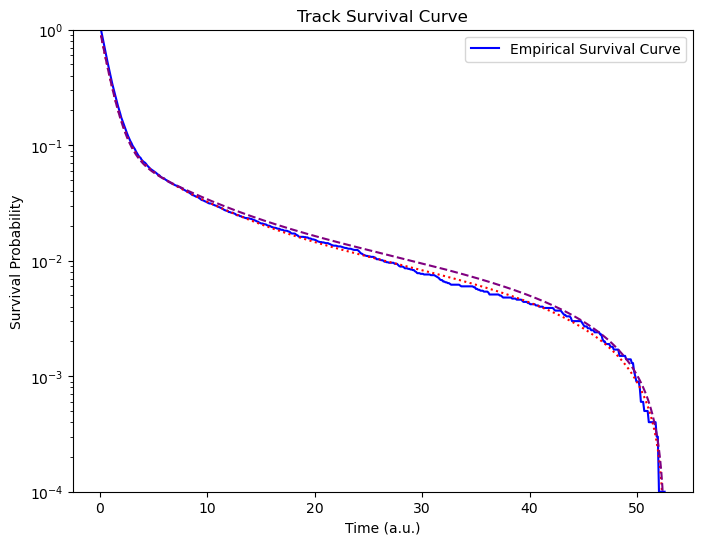

In [35]:
# Compute histogram
hist, bin_edges = np.histogram(residence_times, bins=500, density=True)

# Compute the empirical survival function (reversed cumulative sum)
survival_prob = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
survival_prob = survival_prob / survival_prob[0]  # Normalize

# Create survival dataframe
survival_df = pd.DataFrame({
    'time': bin_edges[1:],  
    'survival_probability': survival_prob
})

# Plot empirical survival curve
plt.figure(figsize=(8, 6))
plt.plot(
    survival_df['time'], 
    survival_df['survival_probability'], 
    label="Empirical Survival Curve",
    color="blue"
)
plt.xlabel("Time (a.u.)")
plt.ylabel("Survival Probability")
plt.title("Track Survival Curve")
plt.yscale('log')
plt.ylim(1e-4,1)
plt.grid(False)

# Function to plot fitted survival curve
def plot_fitted_survival(t, koff_fast, koff_slow, A, B, C, linestyle="dotted", color="red"):
    y_vals = A * np.exp(-koff_fast * t) + B * np.exp(-koff_slow * t) + C * (residence_times.max() - t) / (residence_times.max() - residence_times.min())
    plt.plot(t, y_vals, linestyle=linestyle, color=color)

# Plot Bayesian model fit
plot_fitted_survival(
    survival_df['time'], 
    summary['mean']['koff_fast'], summary['mean']['koff_slow'], 
    summary['mean']['weights[0]'], summary['mean']['weights[1]'], summary['mean']['weights[2]']
)

# Plot ground truth survival function
plot_fitted_survival(
    survival_df['time'], 
    koff_fast_true, koff_slow_true, 
    A_true, B_true, C_true, 
    linestyle="dashed", color="purple"
)
plt.legend()
plt.show()


## REAL DATA

In [36]:
file_path = 'dat/df_tracks.csv'
chunksize = 10000
chunk_list = []
for chunk in pd.read_csv(file_path, chunksize=chunksize):
    chunk_list.append(chunk)

df = pd.concat(chunk_list, ignore_index=True)
df['track_length'] = df['track_length'] * 0.25


In [43]:
# Single FOVs as example data
fov_id_str = '1854872-U2OS-0007_WellG03_Point01'
filtered_data_H2B = df[df['fov_id_str'] == fov_id_str]

fov_id_str = '1854872-U2OS-0007_WellF13_Point00'
filtered_data = df[df['fov_id_str'] == fov_id_str]

In [44]:
# Define bins
residence_times = filtered_data['track_length']

num_bins = 500  # Adjust as needed

bin_edges = np.linspace(0, residence_times.max(), num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers

# Compute histogram
hist_counts, _ = np.histogram(residence_times, bins=bin_edges)

with pm.Model() as double_exp_model:
    # Priors
    alpha = np.array([1, 1, 1])  # Dirichlet prior for fractions
    weights = pm.Dirichlet("weights", a=alpha)

    # Exponential distributions for fast and slow populations
    # Either Uniform or HalfNormal priors will work (HalfNormal example used above)
    koff_slow_lam = pm.Uniform("koff_slow_lam",lower=0,upper=10)
    koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
    koff_alpha = pm.Uniform("koff_alpha",lower=0,upper=10)
    koff_beta = pm.Uniform("koff_beta",lower=0,upper=10)

    koff_fast = pm.Gamma("koff_fast",alpha=koff_alpha,beta=koff_beta)
    pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))
    
    # Constrained Uniform noise term: uniform noise between the minimum and maximum residence time
    noise_min = np.min(bin_centers)
    noise_max = np.max(bin_centers)
    noise_range = noise_max - noise_min  # Calculate the range of residence times
    uniform_noise = 1/(noise_max - noise_min)   
        
    # Expected probability density for each bin center
    expected_density = (
        weights[0] * koff_fast * pm.math.exp(-koff_fast * bin_centers) +
        weights[1] * koff_slow * pm.math.exp(-koff_slow * bin_centers) +
        weights[2] * uniform_noise  # Scaling noise fraction with the noise term
    )

    # Normalize to expected counts (scale by bin width and sample size)
    bin_width = np.diff(bin_edges)
    expected_counts = expected_density * bin_width * len(residence_times)

    # Likelihood: Observed histogram follows a Poisson distribution
    y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)

    # MCMC Sampling
    trace_double = pm.sample(1000, tune=1000, 
                             chains=2, 
                             cores=4,
                             target_accept=0.9,
                             return_inferencedata=True,
                             nuts_sampler="nutpie"
                             )
    pm.compute_log_likelihood(trace_double)


Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.30,15
,2000,0,0.31,7


Output()

In [45]:
# For comparison, this is the fitting for the single exponential model

with pm.Model() as single_exp_model:

    # Mixture weights (signal + noise)
    weights = pm.Dirichlet("weights", a=np.array([1.0, 1.0]))

    # Exponential rate
    koff_lam = pm.Uniform("koff_lam", lower=0, upper=10)
    koff = pm.Exponential("koff", lam=koff_lam)

    # Expected density
    expected_density = (
        weights[0] * koff * pm.math.exp(-koff * bin_centers) +
        weights[1] * uniform_noise
    )

    expected_counts = expected_density * bin_width * len(residence_times)

    y_obs = pm.Poisson(
        "y_obs",
        mu=expected_counts,
        observed=hist_counts
    )

    trace_single = pm.sample(
        1000,
        tune=1000,
        chains=2,
        cores=4,
        target_accept=0.9,
        return_inferencedata=True,
        nuts_sampler="nutpie"
    )
    pm.compute_log_likelihood(trace_single)



Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.81,7
,2000,0,0.81,3


Output()

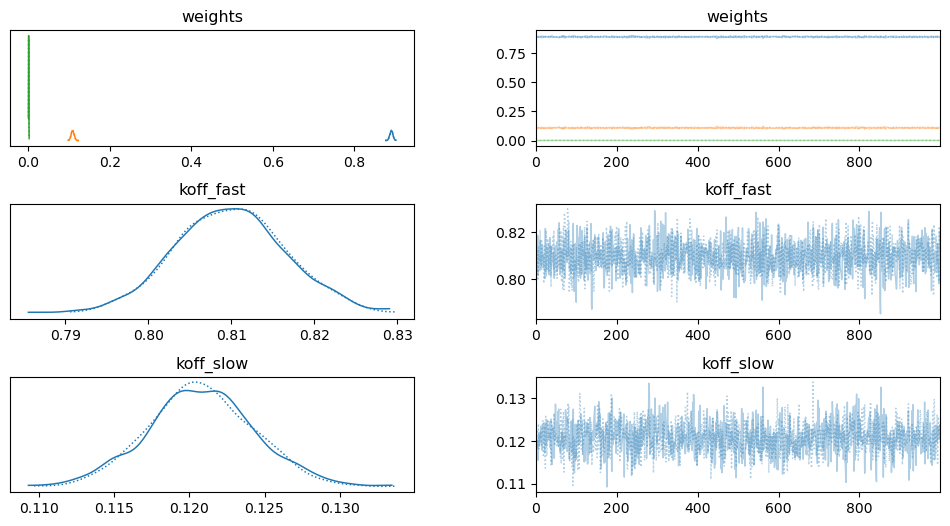

              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
weights[0]  0.8905  0.0036  0.8837   0.8972     0.0001   0.0001  1625.9389   
weights[1]  0.1087  0.0036  0.1017   0.1149     0.0001   0.0001  1832.7196   
weights[2]  0.0009  0.0004  0.0002   0.0015     0.0000   0.0000   332.2871   
koff_fast   0.8098  0.0066  0.7976   0.8228     0.0001   0.0001  2185.1879   
koff_slow   0.1208  0.0036  0.1143   0.1276     0.0001   0.0001  1102.1565   

             ess_tail   r_hat  
weights[0]  1559.3303  1.0005  
weights[1]  1583.7520  1.0002  
weights[2]   428.0359  1.0066  
koff_fast   1580.0565  0.9995  
koff_slow   1434.6422  1.0001  


In [46]:
az.plot_trace(trace_double, var_names=["weights", "koff_fast", "koff_slow"])
plt.subplots_adjust(hspace=0.5, wspace=0.3)  # Increase vertical and horizontal spacing
plt.show()

# Summary statistics
summary = az.summary(
    trace_double, var_names=["weights", "koff_fast", "koff_slow"], round_to=4
)
print(summary)

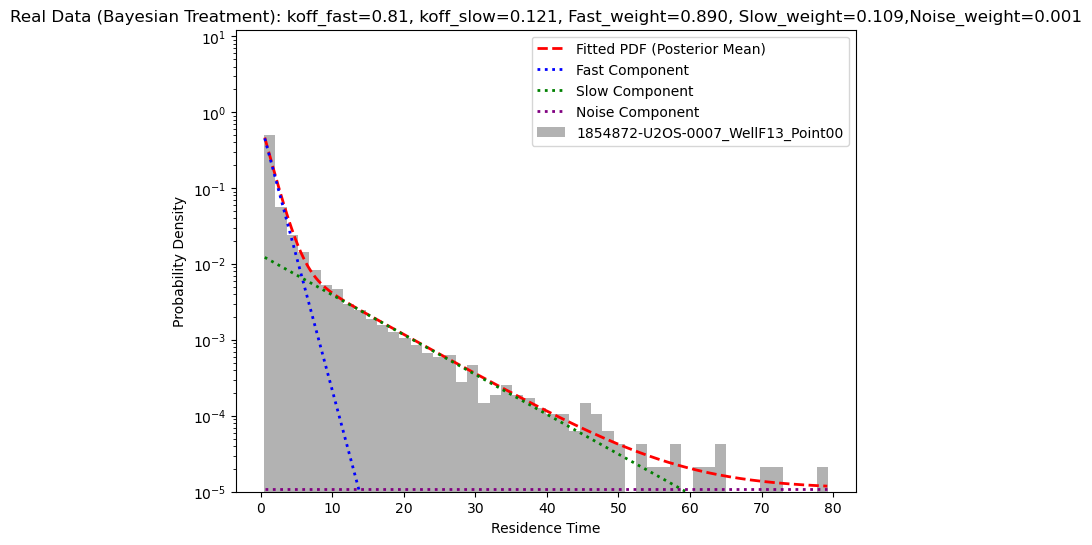

In [47]:
# Extract posterior means from the PyMC trace
trace = trace_double
weights_post = trace.posterior["weights"].mean(dim=("chain", "draw")).values
koff_slow_post = trace.posterior["koff_slow"].mean(dim=("chain", "draw")).values
koff_fast_post = trace.posterior["koff_fast"].mean(dim=("chain", "draw")).values
#noise_fraction_post = trace.posterior["noise_fraction"].mean(dim=("chain", "draw")).values

num_bins = 500  # Adjust as needed
bin_edges = np.linspace(residence_times.min(), residence_times.max(), num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers

# Compute the fitted probability density function
fitted_pdf = (
    weights_post[0] * koff_fast_post * np.exp(-koff_fast_post * bin_centers) +
    weights_post[1] * koff_slow_post * np.exp(-koff_slow_post * bin_centers) +
    (weights_post[2])/(residence_times.max() - 1)  # Normalized uniform noise
)

# Compute each component's probability density
fast_pdf = weights_post[0] * koff_fast_post * np.exp(-koff_fast_post * bin_centers)
slow_pdf = weights_post[1] * koff_slow_post * np.exp(-koff_slow_post * bin_centers)
noise_pdf = [(weights_post[2]) / (residence_times.max() - 1)] * len(bin_centers)



# Compute histogram
hist_counts, _ = np.histogram(residence_times, bins=bin_edges)


# Normalize histogram to probability density
hist_pdf, bin_edges = np.histogram(residence_times, bins=bin_edges, density=True)

# Plot results
plt.figure(figsize=(8, 6))

# Plot histogram as a PDF
plt.plot(bin_centers, fitted_pdf, label="Fitted PDF (Posterior Mean)", color="red", linestyle="dashed", linewidth=2)
# Plot individual components
plt.plot(bin_centers, fast_pdf, label="Fast Component", color="blue", linewidth=2, linestyle="dotted")
plt.plot(bin_centers, slow_pdf, label="Slow Component", color="green", linewidth=2, linestyle="dotted")
plt.plot(bin_centers, noise_pdf, label="Noise Component", color="purple", linewidth=2, linestyle="dotted")


# Plot histogram of simulated data
plt.hist(filtered_data['track_length'], bins=50, density=True, alpha=0.6, color="gray", label=fov_id_str)


# Add labels and legend
plt.xlabel("Residence Time")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.ylim(1e-5)
plt.legend()
plt.title("Comparison of True PDF, Fitted PDF, and Observed Data")

plt.title(f"Real Data (Bayesian Treatment): koff_fast={koff_fast_post:.2f}, koff_slow={koff_slow_post:.3f}, Fast_weight={weights_post[0]:.3f}, Slow_weight={weights_post[1]:.3f},Noise_weight={weights_post[2]:.3f}")
plt.legend()
plt.show()

### Comparison between double and single exponential curve

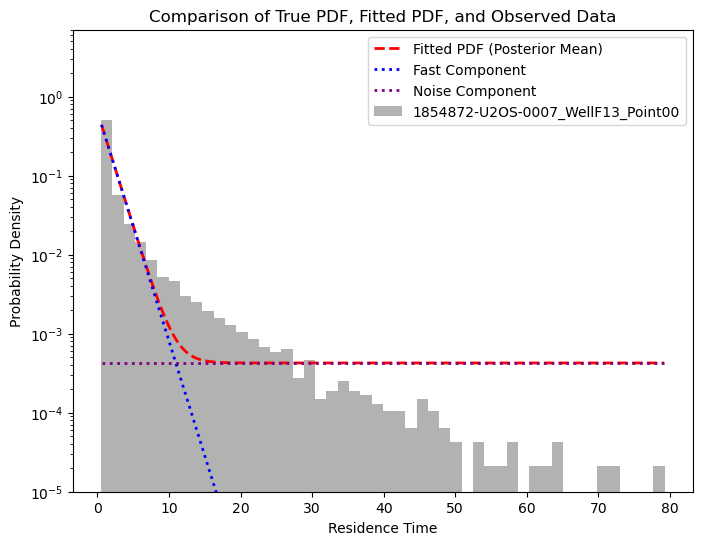

In [48]:
# Extract posterior means from the PyMC trace
trace = trace_single
weights_post = trace.posterior["weights"].mean(dim=("chain", "draw")).values
koff_post = trace.posterior["koff"].mean(dim=("chain", "draw")).values

num_bins = 500  # Adjust as needed
bin_edges = np.linspace(residence_times.min(), residence_times.max(), num_bins + 1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers

# Compute the fitted probability density function
fitted_pdf = (
    weights_post[0] * koff_post * np.exp(-koff_post * bin_centers) +
    (weights_post[1])/(residence_times.max() - 1)  # Normalized uniform noise
)

# Compute each component's probability density
fast_pdf = weights_post[0] * koff_post * np.exp(-koff_post * bin_centers)
noise_pdf = [(weights_post[1]) / (residence_times.max() - 1)] * len(bin_centers)



# Compute histogram
hist_counts, _ = np.histogram(residence_times, bins=bin_edges)


# Normalize histogram to probability density
hist_pdf, bin_edges = np.histogram(residence_times, bins=bin_edges, density=True)

# Plot results
plt.figure(figsize=(8, 6))

# Plot histogram as a PDF
plt.plot(bin_centers, fitted_pdf, label="Fitted PDF (Posterior Mean)", color="red", linestyle="dashed", linewidth=2)
# Plot individual components
plt.plot(bin_centers, fast_pdf, label="Fast Component", color="blue", linewidth=2, linestyle="dotted")
plt.plot(bin_centers, noise_pdf, label="Noise Component", color="purple", linewidth=2, linestyle="dotted")


# Plot histogram of simulated data
plt.hist(filtered_data['track_length'], bins=50, density=True, alpha=0.6, color="gray", label=fov_id_str)


# Add labels and legend
plt.xlabel("Residence Time")
plt.ylabel("Probability Density")
plt.yscale("log")
plt.ylim(1e-5)
plt.legend()
plt.title("Comparison of True PDF, Fitted PDF, and Observed Data")

#plt.title(f"Real Data (Bayesian Treatment): koff_fast={koff_fast_post:.2f}, koff_slow={koff_slow_post:.3f}, Fast_weight={weights_post[0]:.3f}, Slow_weight={weights_post[1]:.3f},Noise_weight={weights_post[2]:.3f}")
plt.legend()
plt.show()



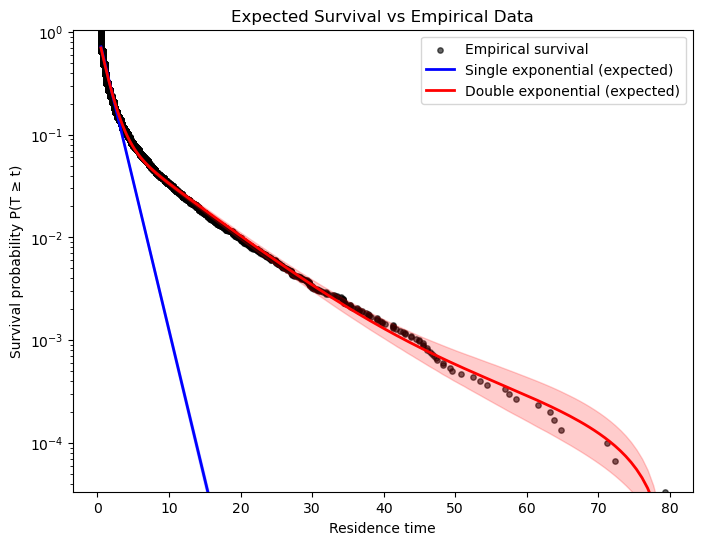

In [49]:
def empirical_ccdf(data):
    sorted_data = np.sort(data)
    n = len(sorted_data)
    survival = np.arange(n, 0, -1) / n
    return sorted_data, survival

# Posterior samples
lam_samples = trace_single.posterior["koff"].values.reshape(-1)

t_grid = np.logspace(
    np.log10(residence_times.min()),
    np.log10(residence_times.max()),
    500
)

# Expected survival
S_single_samples = np.exp(-lam_samples[:, None] * t_grid[None, :])
S_single_mean = S_single_samples.mean(axis=0)
S_single_lo, S_single_hi = np.percentile(S_single_samples, [5, 95], axis=0)

posterior = trace_double.posterior

w = posterior["weights"].values.reshape(-1, 3)
k_fast = posterior["koff_fast"].values.reshape(-1)
k_slow = posterior["koff_slow"].values.reshape(-1)

Tmin = residence_times.min()
Tmax = residence_times.max()

# Survival for each posterior draw
S_double_samples = (
    w[:, 0, None] * np.exp(-k_fast[:, None] * t_grid[None, :]) +
    w[:, 1, None] * np.exp(-k_slow[:, None] * t_grid[None, :])  +
    w[:, 2, None] * (1 - (t_grid[None, :] - Tmin) / (Tmax - Tmin))
)

S_double_mean = S_double_samples.mean(axis=0)
S_double_lo, S_double_hi = np.percentile(S_double_samples, [5, 95], axis=0)

t_sorted, S_emp = empirical_ccdf(residence_times)

plt.figure(figsize=(8, 6))

# Empirical
plt.scatter(
    t_sorted,
    S_emp,
    s=15,
    alpha=0.6,
    color="black",
    label="Empirical survival"
)

# Single exponential
plt.plot(
    t_grid,
    S_single_mean,
    color="blue",
    linewidth=2,
    label="Single exponential (expected)"
)
plt.fill_between(
    t_grid,
    S_single_lo,
    S_single_hi,
    color="blue",
    alpha=0.2
)

# Double exponential
plt.plot(
    t_grid,
    S_double_mean,
    color="red",
    linewidth=2,
    label="Double exponential (expected)"
)
plt.fill_between(
    t_grid,
    S_double_lo,
    S_double_hi,
    color="red",
    alpha=0.2
)

#plt.xscale("log")
plt.yscale("log")
plt.xlabel("Residence time")
plt.ylabel("Survival probability P(T ≥ t)")
plt.ylim(1 / len(residence_times), 1.05)
plt.legend()
plt.title("Expected Survival vs Empirical Data")
plt.show()


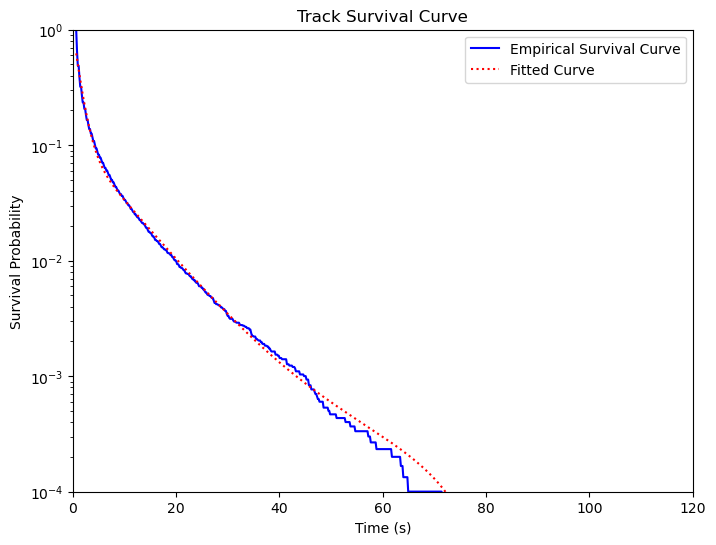

In [50]:
# Compute histogram
hist, bin_edges = np.histogram(residence_times, bins=bin_edges, density=True)

# Compute the empirical survival function (reversed cumulative sum)
survival_prob = np.cumsum(hist[::-1])[::-1]  # Reverse cumulative sum
survival_prob = survival_prob / survival_prob[0]  # Normalize

# Create survival dataframe
survival_df = pd.DataFrame({
    'time': bin_edges[1:],  
    'survival_probability': survival_prob
})

# Plot empirical survival curve
plt.figure(figsize=(8, 6))
plt.plot(
    survival_df['time'], 
    survival_df['survival_probability'], 
    label="Empirical Survival Curve",
    color="blue"
)
plt.xlabel("Time (s)")
plt.ylabel("Survival Probability")
plt.title("Track Survival Curve")
plt.xlim(0,120)
plt.yscale('log')
plt.ylim(1e-4,1)
plt.grid(False)

# Function to plot fitted survival curve
def plot_fitted_survival(t, koff_fast, koff_slow, A, B, C, linestyle="dotted", color="red"):
    y_vals = A * np.exp(-koff_fast * t) + B * np.exp(-koff_slow * t) + C * (t.max() - t) / (t.max() - 1)
    plt.plot(t, y_vals, linestyle=linestyle, color=color,label="Fitted Curve")

# Plot Bayesian model fit
plot_fitted_survival(
    survival_df['time'], 
    summary['mean']['koff_fast'], summary['mean']['koff_slow'], 
    summary['mean']['weights[0]'], summary['mean']['weights[1]'], summary['mean']['weights[2]']
)
plt.legend()
plt.show()


### Overlay of tracks

In [51]:
def fit_fov(residence_times, num_bins=500):
    bin_edges = np.linspace(0, residence_times.max(), num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    hist_counts, _ = np.histogram(residence_times, bins=bin_edges)

    with pm.Model() as model:
        # Mixture weights
        weights = pm.Dirichlet("weights", a=np.array([10, 5, 1]))
        
        # Fast and slow components
        koff_slow_lam = pm.Uniform("koff_slow_lam", lower=0,upper=10)
        koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
        koff_alpha = pm.Uniform("koff_alpha", lower=0,upper=10)
        koff_beta = pm.Uniform("koff_beta", lower=0,upper=10)
        koff_fast = pm.Gamma("koff_fast", alpha=koff_alpha, beta=koff_beta)
        pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))

        # Uniform noise
        noise_min, noise_max = np.min(bin_centers), np.max(bin_centers)
        uniform_noise = 1/(residence_times.max() - residence_times.min())

        # Expected densities
        expected_density = (
            weights[0] * koff_fast * pm.math.exp(-koff_fast * bin_centers) +
            weights[1] * koff_slow * pm.math.exp(-koff_slow * bin_centers) +
            weights[2] * uniform_noise
        )

        expected_counts = expected_density * np.diff(bin_edges) * len(residence_times)
        y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)
        
        trace = pm.sample(1000, tune=1000, chains=2, cores=4, target_accept=0.9,
                          nuts_sampler="nutpie", progressbar=False)
    
    summary = az.summary(trace)
    return trace

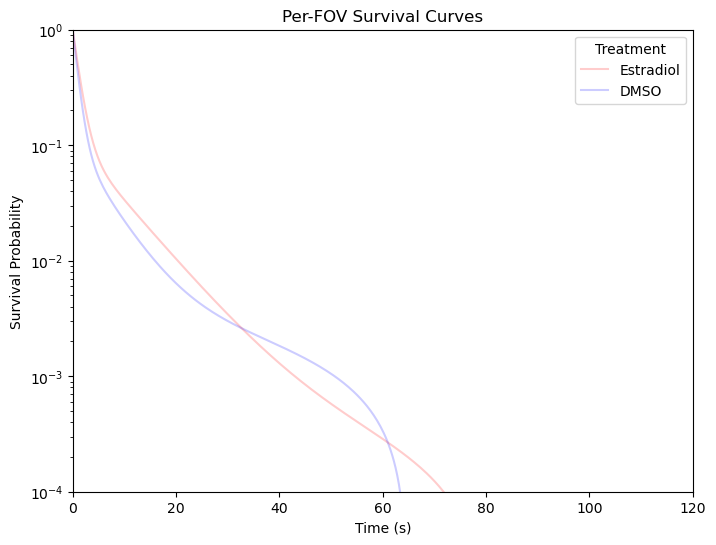

In [52]:
groups = [
    ("DNA-binding mutant (R234A)", "Estradiol", "red"),
    ("DNA-binding mutant (R234A)", "DMSO", "blue")
]

# DNA-binding mutant (R234A)
# RNA-binding mutant #2 (R)
# RNA-binding mutant #3 (RRGG, RG)
# WT ERa pool
# RNA-binding mutant #1 (RRGG)

plt.figure(figsize=(8, 6))

# --- Fit and plot each group ---
for cell_line, molecule, color in groups:
    group_df = df[
        (df['Cell Line ID'] == cell_line) &
        (df['Molecule Name'] == molecule)
    ]

    fov_ids = group_df['fov_id_str'].unique()

    for i, fov_id in enumerate(fov_ids):
        filtered_data = group_df[group_df['fov_id_str'] == fov_id]
        residence_times = filtered_data['track_length'].values

        trace = fit_fov(residence_times)

        # Extract posterior means
        weights = trace.posterior["weights"].mean(dim=("chain", "draw")).values
        koff_fast = trace.posterior["koff_fast"].mean(dim=("chain", "draw")).values
        koff_slow = trace.posterior["koff_slow"].mean(dim=("chain", "draw")).values

        # Compute survival curve
        t = np.linspace(0, residence_times.max(), 200)
        y_fit = (
            weights[0] * np.exp(-koff_fast * t) +
            weights[1] * np.exp(-koff_slow * t) +
            weights[2] * (t.max() - t) / (t.max() - 1)
        )

        plt.plot(
            t, y_fit,
            alpha=0.2,
            color=color,
            label=f"{molecule}" if i == 0 else None
        )

# --- Formatting ---
plt.xlim(0, 120)
plt.yscale('log')
plt.ylim(1e-4, 1)
plt.xlabel("Time (s)")
plt.ylabel("Survival Probability")
plt.title("Per-FOV Survival Curves")
plt.legend(title="Treatment")
plt.show()


Representative FOV: 1854872-U2OS-0007_WellJ10_Point00


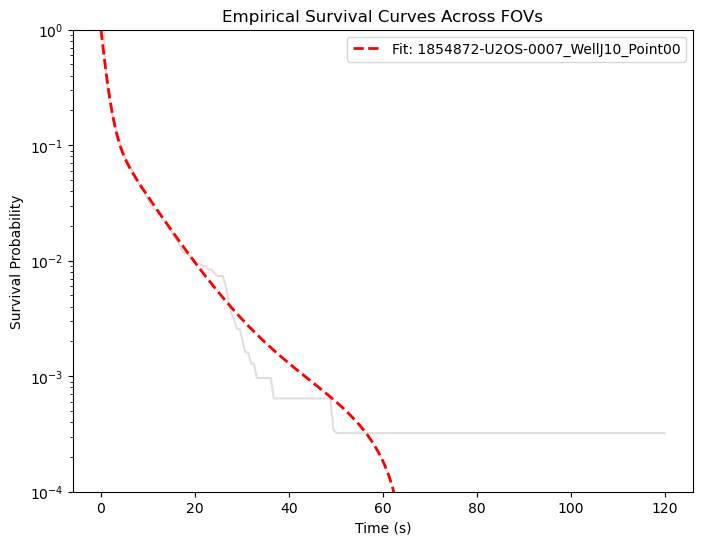

In [53]:
# DNA-binding mutant (R234A)
# RNA-binding mutant #2 (R)
# RNA-binding mutant #3 (RRGG, RG)
# WT ERa pool
# RNA-binding mutant #1 (RRGG)

group_df = df[
    (df['Cell Line ID'] == 'RNA-binding mutant #3 (RRGG, RG)') &
    (df['Molecule Name'] == 'DMSO')
]

fov_ids = group_df['fov_id_str'].unique()
rep_fov_id = np.random.choice(fov_ids)
#rep_fov_id = '1854872-U2OS-0005_WellG13_Point03'
print(f"Representative FOV: {rep_fov_id}")

rep_data = group_df[group_df['fov_id_str'] == rep_fov_id]['track_length'].values

t_grid = np.linspace(0, 120, 200)
plt.figure(figsize=(8,6))

for fov_id in fov_ids:
    fov_data = group_df[group_df['fov_id_str'] == fov_id]['track_length'].values
    
    hist, bin_edges = np.histogram(fov_data, bins=500, density=True)
    survival_prob = np.cumsum(hist[::-1])[::-1]
    survival_prob /= survival_prob[0]
    
    survival_interp = np.interp(t_grid, bin_edges[1:], survival_prob)
    plt.plot(t_grid, survival_interp, alpha=0.25, color='gray')

plt.xlabel("Time (s)")
plt.ylabel("Survival Probability")
plt.yscale('log')
plt.ylim(1e-4,1)
plt.title("Empirical Survival Curves Across FOVs")

num_bins = 500
bin_edges = np.linspace(0, rep_data.max(), num_bins+1)
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
hist_counts, _ = np.histogram(rep_data, bins=bin_edges)

with pm.Model() as model:
    weights = pm.Dirichlet("weights", a=np.array([10,5,1]))
    koff_slow_lam = pm.Uniform("koff_slow_lam", lower=0,upper=10)
    koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
    koff_alpha = pm.Uniform("koff_alpha", lower=0,upper=10)
    koff_beta = pm.Uniform("koff_beta", lower=0,upper=10)
    koff_fast = pm.Gamma("koff_fast", alpha=koff_alpha, beta=koff_beta)
    pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))
    
    uniform_noise = 1/(rep_data.max() - 1)
    expected_density = (
        weights[0]*koff_fast*pm.math.exp(-koff_fast*bin_centers) +
        weights[1]*koff_slow*pm.math.exp(-koff_slow*bin_centers) +
        (weights[2]*uniform_noise)
    )
    expected_counts = expected_density * np.diff(bin_edges) * len(rep_data)
    
    y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)
    trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, nuts_sampler="nutpie", progressbar=False)

weights_post = trace.posterior["weights"].mean(dim=("chain","draw")).values
koff_fast_post = trace.posterior["koff_fast"].mean(dim=("chain","draw")).values
koff_slow_post = trace.posterior["koff_slow"].mean(dim=("chain","draw")).values

fitted_survival = (
    weights_post[0]*np.exp(-koff_fast_post*t_grid) +
    weights_post[1]*np.exp(-koff_slow_post*t_grid) +
    weights_post[2]*(rep_data.max()-t_grid)/(rep_data.max()-1)
)

plt.plot(t_grid, fitted_survival, color='red', linewidth=2, linestyle='--', label=f'Fit: {rep_fov_id}')
plt.legend()
plt.show()


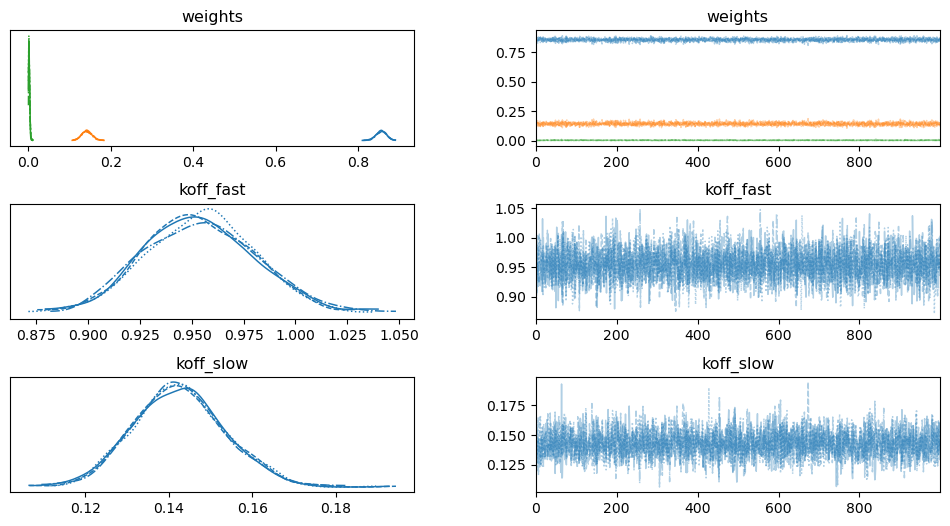

              mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd   ess_bulk  \
weights[0]  0.8560  0.0124  0.8324   0.8786     0.0002   0.0001  3930.0296   
weights[1]  0.1419  0.0123  0.1190   0.1650     0.0002   0.0001  4015.2349   
weights[2]  0.0021  0.0014  0.0001   0.0047     0.0000   0.0000   871.6028   
koff_fast   0.9541  0.0270  0.9049   1.0046     0.0004   0.0003  3704.0056   
koff_slow   0.1425  0.0110  0.1222   0.1629     0.0002   0.0001  3211.4964   

             ess_tail   r_hat  
weights[0]  3332.9084  1.0012  
weights[1]  3422.5136  1.0011  
weights[2]   859.0737  1.0030  
koff_fast   2884.8793  1.0004  
koff_slow   2774.5111  1.0000  


In [54]:
az.plot_trace(trace, var_names=["weights", "koff_fast", "koff_slow"])
plt.subplots_adjust(hspace=0.5, wspace=0.3)  # Increase vertical and horizontal spacing
plt.show()

# Summary statistics
summary = az.summary(
    trace, var_names=["weights", "koff_fast", "koff_slow"], round_to=4
)
print(summary)

## Attempting Bayesian fits on whole dataset

In [ ]:
def fit_model(fov_id, df):
    # Subset the data for the current fov_id_str
    subset_data = df[df["fov_id_str"] == fov_id]

    # Define bins
    residence_times = subset_data['track_length']
    
    num_bins = 500  # Adjust as needed
    bin_edges = np.linspace(1, 120, num_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # Get bin centers
    
    # Compute histogram
    hist_counts, _ = np.histogram(residence_times, bins=bin_edges)

    with pm.Model() as model:
        # Priors
        alpha = np.array([1, 1, 1])  # Dirichlet prior for fractions
        weights = pm.Dirichlet("weights", a=alpha)
    
        # Exponential distributions for fast and slow populations
        koff_slow_lam = pm.Uniform("koff_slow_lam",lower=0,upper=10)
        koff_slow = pm.Exponential("koff_slow", lam=koff_slow_lam)
        koff_alpha = pm.Uniform("koff_alpha",lower=0,upper=10)
        koff_beta = pm.Uniform("koff_beta",lower=0,upper=10)
    
        koff_fast = pm.Gamma("koff_fast",alpha=koff_alpha,beta=koff_beta)
        pm.Potential("valid_koff", pm.math.switch(koff_fast > koff_slow, 0, -np.inf))
        
        # Constrained Uniform noise term: uniform noise between the minimum and maximum residence time
        noise_min = np.min(bin_centers)
        noise_max = np.max(bin_centers)
        noise_range = noise_max - noise_min  # Calculate the range of residence times
        uniform_noise = 1/(noise_max - noise_min)   
            
        # Expected probability density for each bin center
        expected_density = (
            weights[0] * koff_fast * pm.math.exp(-koff_fast * bin_centers) +
            weights[1] * koff_slow * pm.math.exp(-koff_slow * bin_centers) +
            weights[2] * uniform_noise  # Scaling noise fraction with the noise term
        )
    
        # Normalize to expected counts (scale by bin width and sample size)
        bin_width = np.diff(bin_edges)
        expected_counts = expected_density * bin_width * len(residence_times)
    
        # Likelihood: Observed histogram follows a Poisson distribution
        y_obs = pm.Poisson("y_obs", mu=expected_counts, observed=hist_counts)
    
        # MCMC Sampling
        trace = pm.sample(1000, tune=1000, chains=4, target_accept=0.95, nuts_sampler="nutpie")

    summary = az.summary(trace, var_names=["weights", "koff_slow", "koff_fast"], hdi_prob=0.94)
    summary["fov_id_str"] = fov_id
    return summary


In [ ]:
unique_fov_ids = df["fov_id_str"].unique()

# Container to store results
results = []

logger = logging.getLogger("pymc")
logger.setLevel(logging.WARNING)

def run_fit(fov_id):
    """Wrapper function for parallel execution"""
    return fit_model(fov_id, df)

In [ ]:
start_time = time.time()  # Start timing
for i, fov_id in enumerate(unique_fov_ids, start=1):
    summary = fit_model(fov_id, df)
    results.append(summary)

end_time = time.time()  # End timing
elapsed_time = end_time - start_time  # Compute elapsed time

print(f"Total job time: {elapsed_time:.2f} seconds ({elapsed_time/60:.2f} minutes)")


In [ ]:
combined_df = pd.concat(results, ignore_index=False)